In [10]:
import numpy as np
import pandas as pd
import galpy
import astropy
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [11]:
# NASA exoplanet archive
nasa = pd.read_csv("NASA exoplanet Archive (filtered Columns) 1 (Degrees).csv",
                   skiprows=30)
nasa = nasa[nasa["gaia_dr3_id"].notna()].copy()
nasa["gaia_id_clean"] = (nasa["gaia_dr3_id"]
                          .astype(str)
                          .str.replace("Gaia DR3 ", "", regex=False)
                          .str.strip())

#Drop fully identical rows, keep one per Gaia ID
nasa = nasa.drop_duplicates(subset="gaia_id_clean", keep="first")
nasa_ids = set(nasa["gaia_id_clean"])

# GALAH DR3 main catalog (stellar parameters + chemical abundances)
galah = pd.read_csv("GALAH_DR3_main_catalog.csv")

# GALAH DR3 dynamics
dynamics = pd.read_csv("GALAH_DR3_dynamics_catalog.csv")

galah["gaia_id_clean"] = galah["dr3_source_id"].astype(str).str.strip()

C:\Users\StanM\AppData\Local\Temp\ipykernel_18892\3090666347.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  galah = pd.read_csv("GALAH_DR3_main_catalog.csv")



In [12]:
# Save first 200 rows of each file as CSV for inspection
galah.head(200).to_csv("galah_sample_200.csv", index=False)
print("Columns in GALAH main file:")
print(list(galah.columns))

dynamics.head(200).to_csv("dynamics_sample_200.csv", index=False)
print("Columns in GALAH dynamics file:")
print(list(dynamics.columns))

Columns in GALAH main file:
['star_id', 'sobject_id', 'dr2_source_id', 'dr3_source_id', 'survey_name', 'field_id', 'flag_repeat', 'wg4_field', 'wg4_pipeline', 'flag_sp', 'teff', 'e_teff', 'irfm_teff', 'irfm_ebv', 'irfm_ebv_ref', 'logg', 'e_logg', 'fe_h', 'e_fe_h', 'flag_fe_h', 'fe_h_atmo', 'vmic', 'vbroad', 'e_vbroad', 'chi2_sp', 'alpha_fe', 'e_alpha_fe', 'nr_alpha_fe', 'flag_alpha_fe', 'flux_A_Fe', 'chi_A_Fe', 'Li_fe', 'e_Li_fe', 'nr_Li_fe', 'flag_Li_fe', 'C_fe', 'e_C_fe', 'nr_C_fe', 'flag_C_fe', 'O_fe', 'e_O_fe', 'nr_O_fe', 'flag_O_fe', 'Na_fe', 'e_Na_fe', 'nr_Na_fe', 'flag_Na_fe', 'Mg_fe', 'e_Mg_fe', 'nr_Mg_fe', 'flag_Mg_fe', 'Al_fe', 'e_Al_fe', 'nr_Al_fe', 'flag_Al_fe', 'Si_fe', 'e_Si_fe', 'nr_Si_fe', 'flag_Si_fe', 'K_fe', 'e_K_fe', 'nr_K_fe', 'flag_K_fe', 'Ca_fe', 'e_Ca_fe', 'nr_Ca_fe', 'flag_Ca_fe', 'Sc_fe', 'e_Sc_fe', 'nr_Sc_fe', 'flag_Sc_fe', 'Sc2_fe', 'e_Sc2_fe', 'nr_Sc2_fe', 'flag_Sc2_fe', 'Ti_fe', 'e_Ti_fe', 'nr_Ti_fe', 'flag_Ti_fe', 'Ti2_fe', 'e_Ti2_fe', 'nr_Ti2_fe', 'flag_

In [13]:
# choose the best observation per star using SNR, before any merge
galah = (galah
         .sort_values("snr_c3_iraf", ascending=False)
         .drop_duplicates(subset="gaia_id_clean", keep="first"))

In [14]:
# GALAH main + dynamics VAC
galah_all = galah.merge(
    dynamics,
    on="sobject_id",
    how="left"
)
print(f"GALAH combined: {len(galah_all):,}")

#NASA + GALAH (inner join on Gaia DR3 ID)
nasa_galah = nasa.merge(
    galah_all,
    on="gaia_id_clean",
    how="inner"
)
print(f"Combined NASA + GALAH: {len(nasa_galah):,} rows")

GALAH combined: 588,465
Combined NASA + GALAH: 171 rows


In [15]:
#Save full GALAH catalog
galah_all.to_csv("galah_dr3_full_catalog.csv", index=False)
print("Saved galah_dr3_full_catalog.csv")

#Save NASA + GALAH matched file
nasa_galah.to_csv("exoplanet_hosts_galah_NASA_matched.csv", index=False)
print("Saved exoplanet_hosts_galah_NASA_matched.csv")

Saved galah_dr3_full_catalog.csv
Saved exoplanet_hosts_galah_NASA_matched.csv


In [16]:
#Quality cuts on combined file
# Not removing null data as some of these are just missing values, not necessarily bad data.
nasa_galah["plx_frac_err"] = nasa_galah['sy_plxerr1'] / nasa_galah['sy_plx']

clean_hosts = nasa_galah[
    (nasa_galah["snr_c3_iraf"].isna()  | (nasa_galah["snr_c3_iraf"] >= 15))  &
    (nasa_galah["flag_sp"].isna()       | (nasa_galah["flag_sp"]      == 0))  &
    (nasa_galah["flag_fe_h"].isna()     | (nasa_galah["flag_fe_h"]    == 0))  &
    (nasa_galah["flag_guess"].isna()    | (nasa_galah["flag_guess"]   == 0))  &
    (nasa_galah["red_flag"].isna()      | (nasa_galah["red_flag"]     == 0))  &
    (nasa_galah["e_teff"].isna()        | (nasa_galah["e_teff"]       < 200)) &
    (nasa_galah["e_logg"].isna()        | (nasa_galah["e_logg"]       < 0.25))&
    (nasa_galah["e_fe_h"].isna()        | (nasa_galah["e_fe_h"]       < 0.2)) &
    (nasa_galah["e_alpha_fe"].isna()    | (nasa_galah["e_alpha_fe"]   < 0.05))&
    (nasa_galah["teff"].isna()          | (nasa_galah["teff"].between(3500, 5500))) &
    (nasa_galah["plx_frac_err"].isna()  | (nasa_galah["plx_frac_err"] <= 0.20))
].copy()

print(f"After quality cuts: {len(clean_hosts):,} rows")
print(f"Retention: {100 * len(clean_hosts) / len(nasa_galah):.1f}%")

#Quality cuts on full GALAH combined file
galah_all = pd.read_csv("galah_dr3_full_catalog.csv")
galah_clean = galah_all[
    (galah_all["snr_c3_iraf"].isna() | (galah_all["snr_c3_iraf"] >= 30)) &
    (galah_all["flag_sp"].isna()      | (galah_all["flag_sp"]      == 0)) &
    (galah_all["flag_fe_h"].isna()    | (galah_all["flag_fe_h"]    == 0)) &
    (galah_all["flag_guess"].isna()   | (galah_all["flag_guess"]   == 0)) &
    (galah_all["red_flag"].isna()     | (galah_all["red_flag"]     == 0)) &
    (galah_all["teff"].isna()         | (galah_all["teff"].between(3500, 5500)))
].copy()

print(f"After quality cuts: {len(galah_clean):,} rows")
print(f"Retention: {100 * len(galah_clean) / len(galah_all):.1f}%")

After quality cuts: 39 rows
Retention: 22.8%
After quality cuts: 161,908 rows
Retention: 27.5%


In [17]:
#Orbit integration
orbit_sample = clean_hosts[
    clean_hosts["rv_galah"].notna() &
    (clean_hosts["sy_plx"] > 0)
].copy().reset_index(drop=True)

n = len(orbit_sample)
print(f"Stars with valid RV: {n}")

# Initialise arrays
v_x_galcen     = np.full(n, np.nan)
v_y_galcen     = np.full(n, np.nan)
v_z_galcen     = np.full(n, np.nan)
v_total_galcen = np.full(n, np.nan)
Lz             = np.full(n, np.nan)
ecc            = np.full(n, np.nan)
E              = np.full(n, np.nan)
X_galcen       = np.full(n, np.nan)
Y_galcen       = np.full(n, np.nan)
Z_galcen       = np.full(n, np.nan)

for i in range(n):
    try:
        o = Orbit(
            [
                orbit_sample["ra"].iloc[i],
                orbit_sample["dec"].iloc[i],
                1.0 / orbit_sample["sy_plx"].iloc[i],   # distance in kpc
                orbit_sample["sy_pmra"].iloc[i],
                orbit_sample["sy_pmdec"].iloc[i],
                orbit_sample["rv_galah"].iloc[i],
            ],
            radec=True, solarmotion="schoenrich", ro=8.0, vo=220,
        )
        v_x_galcen[i]     = o.vx(use_physical=True)
        v_y_galcen[i]     = o.vy(use_physical=True)
        v_z_galcen[i]     = o.vz(use_physical=True)
        v_total_galcen[i] = np.sqrt(v_x_galcen[i]**2 + v_y_galcen[i]**2 + v_z_galcen[i]**2)
        Lz[i]             = o.Lz(use_physical=True)
        ecc[i]            = o.e(use_physical=True, pot=MWPotential2014, analytic=True)
        E[i]              = o.E(use_physical=True, pot=MWPotential2014)
        X_galcen[i]       = o.x(use_physical=True)
        Y_galcen[i]       = o.y(use_physical=True)
        Z_galcen[i]       = o.z(use_physical=True)

    except Exception as e:
        print(f"Error at star {i}: {e}")

print(f"Orbits computed for {(~np.isnan(Lz)).sum()} / {n} stars")

# Add orbit columns to orbit_sample
orbit_sample["v_x_galcen"]     = v_x_galcen
orbit_sample["v_y_galcen"]     = v_y_galcen
orbit_sample["v_z_galcen"]     = v_z_galcen
orbit_sample["v_total_galcen"] = v_total_galcen
orbit_sample["Lz_orbit"]       = Lz
orbit_sample["e_orbit"]        = ecc
orbit_sample["E_orbit"]        = E
orbit_sample["X_galcen"]       = X_galcen
orbit_sample["Y_galcen"]       = Y_galcen
orbit_sample["Z_galcen"]       = Z_galcen

#Merge orbit columns back into clean_hosts (NaN for stars without RV
orbit_cols = ["gaia_id_clean", "v_x_galcen", "v_y_galcen", "v_z_galcen",
              "v_total_galcen", "Lz_orbit", "e_orbit", "E_orbit",
              "X_galcen", "Y_galcen", "Z_galcen"]

clean_hosts = clean_hosts.merge(orbit_sample[orbit_cols], on="gaia_id_clean", how="left")

clean_hosts.to_csv("exoplanet_hosts_galah_with_orbits.csv", index=False)
print("Saved exoplanet_hosts_galah_with_orbits.csv")

Stars with valid RV: 39
Orbits computed for 39 / 39 stars
Saved exoplanet_hosts_galah_with_orbits.csv


In [18]:
# MONTE CARLO UNCERTAINTIES FOR TOOMRE DIAGRAM ONLY

N_MC = 1000

vygalcen    = np.full(n, np.nan)
vy_err      = np.full(n, np.nan)
vperp       = np.full(n, np.nan)
vperp_err   = np.full(n, np.nan)

for i in range(n):
    try:
        row = orbit_sample.iloc[i]
        vxs, vys, vzs = [], [], []

        plx_samples  = np.random.normal(row['sy_plx'],   row['sy_plxerr1'],   N_MC)
        pmra_samples = np.random.normal(row['sy_pmra'],  row['sy_pmraerr1'],  N_MC)
        pmde_samples = np.random.normal(row['sy_pmdec'], row['sy_pmdecerr1'], N_MC)
        rv_samples   = np.random.normal(row['rv_galah'],    row['e_rv_galah'],    N_MC)

        for j in range(N_MC):
            if plx_samples[j] <= 0:
                continue
            try:
                o = Orbit(
                    [row['ra'], row['dec'],
                     1.0 / plx_samples[j],
                     pmra_samples[j], pmde_samples[j], rv_samples[j]],
                    radec=True, solarmotion='schoenrich', ro=8.0, vo=220,
                )
                vxs.append(o.vx(use_physical=True))
                vys.append(o.vy(use_physical=True))
                vzs.append(o.vz(use_physical=True))
            except Exception:
                continue

        if len(vys) < 10:
            continue

        # Vy: median + 1-sigma from 16th/84th percentiles
        p16, p50, p84 = np.percentile(vys, [16, 50, 84])
        vygalcen[i] = p50
        vy_err[i]   = (p84 - p16) / 2

        # Vperp = sqrt(Vx^2 + Vz^2): median + uncertainty
        vperp_arr = np.sqrt(np.array(vxs)**2 + np.array(vzs)**2)
        p16, p50, p84 = np.percentile(vperp_arr, [16, 50, 84])
        vperp[i]     = p50
        vperp_err[i] = (p84 - p16) / 2

    except Exception as e:
        print(f"Error at star {i}: {e}")

# Attach to orbit_sample
orbit_sample['vygalcen']  = vygalcen
orbit_sample['vy_err']    = vy_err
orbit_sample['vperp']     = vperp
orbit_sample['vperp_err'] = vperp_err

# Per-survey uncertainty summary
valid = ~np.isnan(vy_err)
print("  Galah — Toomre Diagram Kinematic Uncertainties")
print(f"  N stars with valid MC runs : {valid.sum()} / {n}")
print(f"  Median sigma(V_Y)              : {np.nanmedian(vy_err):.3f} km/s")
print(f"  Median sigma(V_perp)           : {np.nanmedian(vperp_err):.3f} km/s")




  Galah — Toomre Diagram Kinematic Uncertainties
  N stars with valid MC runs : 39 / 39
  Median sigma(V_Y)              : 0.098 km/s
  Median sigma(V_perp)           : 0.138 km/s


In [19]:

#Average chemical uncertainties
feh_unc_avg   = clean_hosts["e_fe_h"].dropna().mean()
feh_unc_n     = clean_hosts["e_fe_h"].dropna().count()

alpha_unc_avg = clean_hosts["e_alpha_fe"].dropna().mean()
alpha_unc_n   = clean_hosts["e_alpha_fe"].dropna().count()

print(f"  [Fe/H]   mean: {feh_unc_avg:.4f} dex,  N={feh_unc_n}")
print(f"  [alpha/Fe]   mean: {alpha_unc_avg:.4f} dex,  N={alpha_unc_n}")

  [Fe/H]   mean: 0.0619 dex,  N=39
  [alpha/Fe]   mean: 0.0287 dex,  N=39


plot1_alpha_feh.png


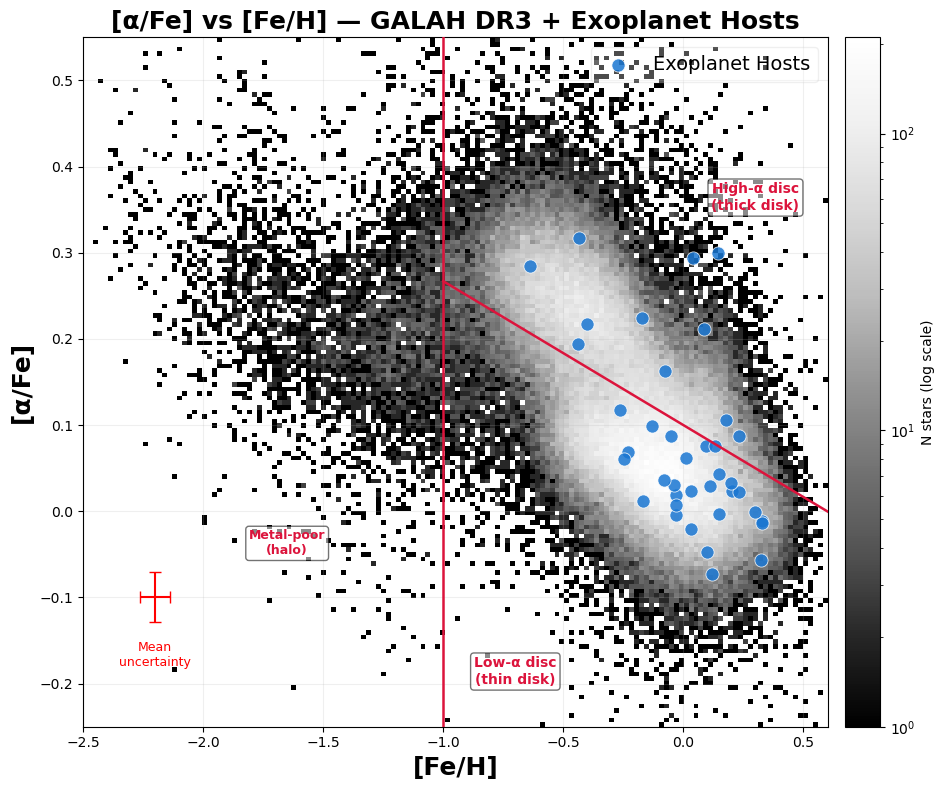

plot2_toomre.png


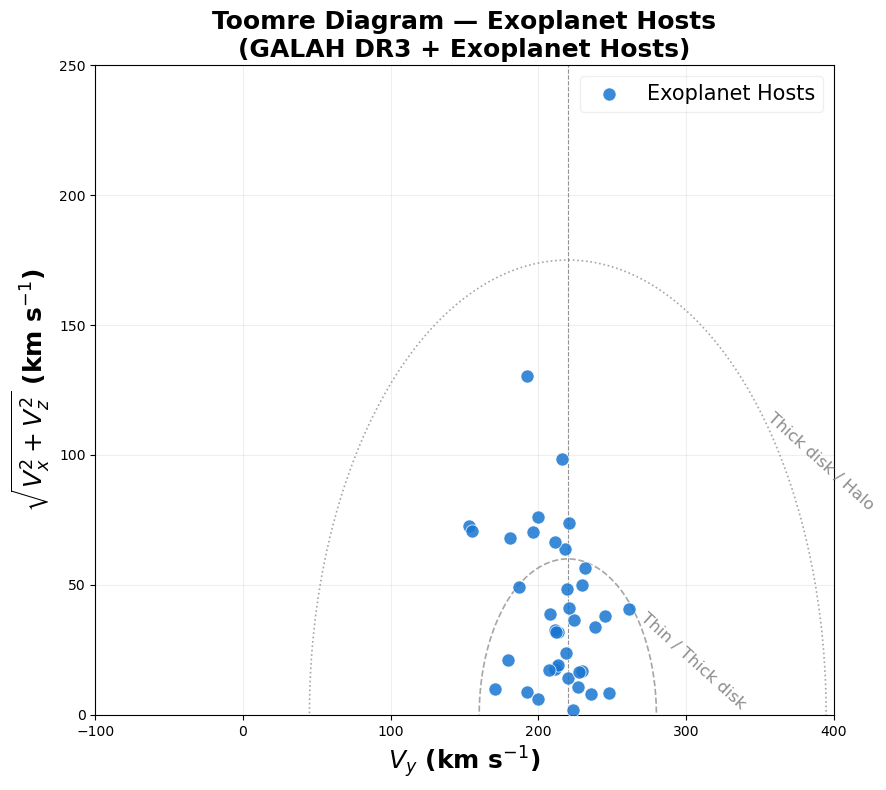

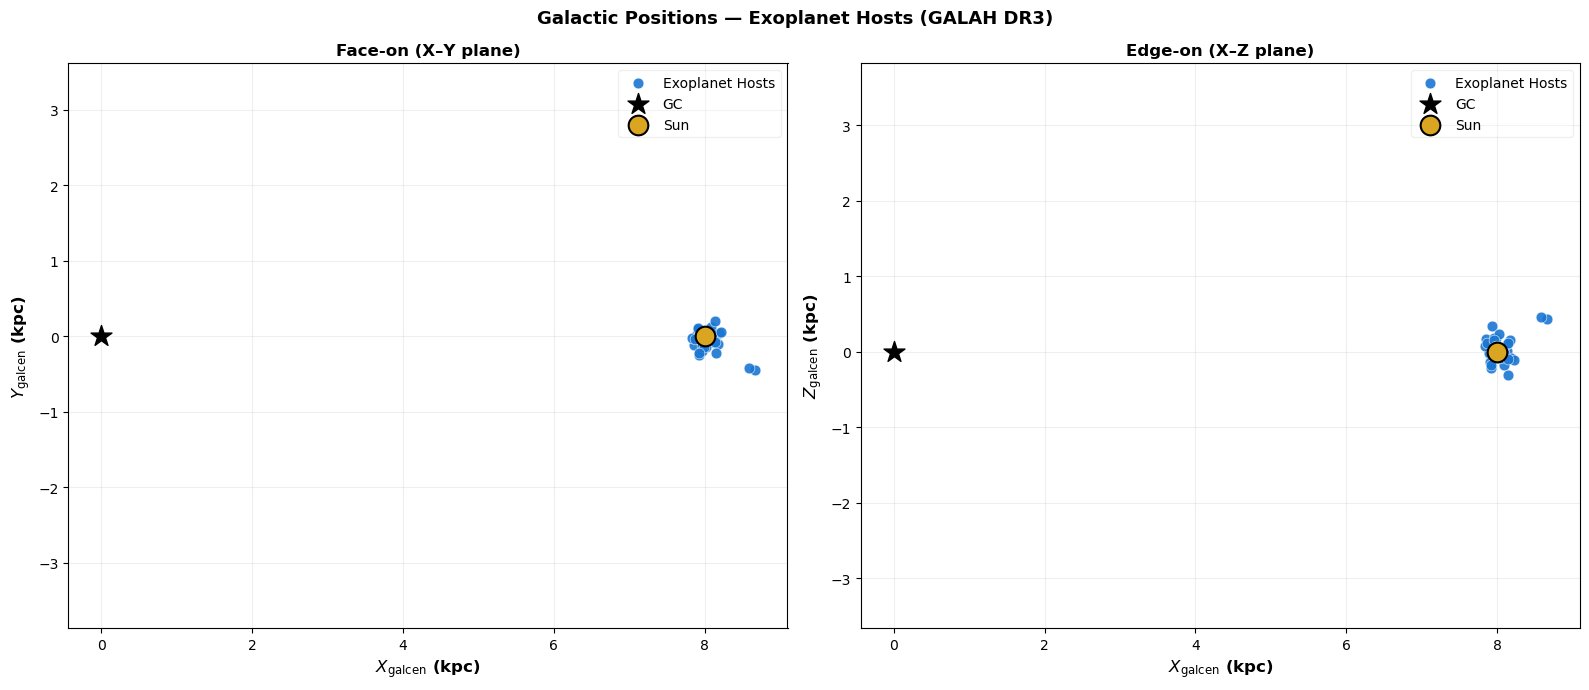

In [20]:
#Boundaries for chemical classification
FEH_CUT    = -1.0    # vertical line separating metal-poor halo from in-situ disc
DIAG_SLOPE = -0.167  # slope of the high alpha / low alpha diagonal boundary
DIAG_INT   =  0.1   # intercept

# PLOT 1: Chemical abundancies 

bg = galah_clean.dropna(subset=["fe_h", "alpha_fe"])

fig, ax = plt.subplots(figsize=(10, 8))
h = ax.hist2d(bg["fe_h"], bg["alpha_fe"],
              bins=150, range=[[-2.5, 0.6], [-0.25, 0.55]],
              cmap="Greys_r", norm=LogNorm(), zorder=1)
plt.colorbar(h[3], ax=ax, label="N stars (log scale)", pad=0.02)

g = clean_hosts.dropna(subset=["fe_h", "alpha_fe"])
ax.scatter(g["fe_h"], g["alpha_fe"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label="Exoplanet Hosts")


# Representative error cross - bottom-left corner
ax.errorbar(-2.2, -0.1,
            xerr=0.062, yerr=0.029,
            fmt='none', color='red', capsize=4,
            linewidth=1.5, zorder=10)
ax.text(-2.2, -0.15, 'Mean\nuncertainty',
        ha='center', va='top', fontsize=9, color='red')


# 1) Vertical cut
ax.axvline(FEH_CUT, color="crimson", lw=1.8, ls="-", zorder=6)

# 2) Diagonal cut — drawn only for [Fe/H] ≥ FEH_CUT
feh_diag = np.linspace(FEH_CUT, 0.6, 300)
ax.plot(feh_diag, DIAG_SLOPE * feh_diag + DIAG_INT,
        color="crimson", lw=1.8, ls="-", zorder=6)

# Region labels
ax.text(0.3,  0.35, "High-α disc\n(thick disk)",
        color="crimson", fontsize=10, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))
ax.text(-0.7, -0.2, "Low-α disc\n(thin disk)",
        color="crimson", fontsize=10, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))
ax.text(-1.65, -0.05, "Metal-poor\n(halo)",
        color="crimson", fontsize=9,  fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))

ax.set_xlabel("[Fe/H]",   fontsize=18, fontweight="bold")
ax.set_ylabel("[α/Fe]",   fontsize=18, fontweight="bold")
ax.set_title("[α/Fe] vs [Fe/H] — GALAH DR3 + Exoplanet Hosts",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=14, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot1_alpha_feh.png", dpi=300, bbox_inches="tight")
print("plot1_alpha_feh.png")
plt.show()


# PLOT 2 — Toomre Diagram

clean_hosts["V_perp"] = np.sqrt(clean_hosts["v_x_galcen"]**2 + clean_hosts["v_z_galcen"]**2)

V_LSR = 220.0

fig, ax = plt.subplots(figsize=(9, 8))

g = clean_hosts.dropna(subset=["v_y_galcen", "V_perp"])
ax.scatter(g["v_y_galcen"], g["V_perp"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label="Exoplanet Hosts")

for v_bound, ls, pop_label in [(60, "--", "Thin / Thick disk"), (175, ":", "Thick disk / Halo")]:
    theta = np.linspace(-1, np.pi, 300)   # upper half only since y >= 0
    ax.plot(V_LSR + v_bound * np.cos(theta),
            v_bound * np.sin(theta),
            color="grey", ls=ls, lw=1.2, alpha=0.7)
    # Place label on the arc at chosen angle
    angle_deg = 42
    angle_rad = np.radians(angle_deg)
    lx = V_LSR + v_bound * np.cos(angle_rad)
    ly = v_bound * np.sin(angle_rad)
    ax.text(lx + 3, ly, pop_label,
            color="grey", fontsize=12, alpha=0.9,
            rotation=-angle_deg,
            ha="left", va="top")

ax.axvline(V_LSR, color="grey", lw=0.8, alpha=0.6, ls="--")
ax.set_ylim(0,250)
ax.set_xlim(-100,400)

ax.axvline(V_LSR, color="grey", lw=0.8, alpha=0.6, ls="--")
ax.set_xlabel("$V_y$ (km s$^{-1}$)", fontsize=18, fontweight="bold")
ax.set_ylabel(r"$\sqrt{V_x^2 + V_z^2}$ (km s$^{-1}$)", fontsize=18, fontweight="bold")
ax.set_title("Toomre Diagram — Exoplanet Hosts\n(GALAH DR3 + Exoplanet Hosts)",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=15, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot2_toomre.png", dpi=300, bbox_inches="tight")
print("plot2_toomre.png")
plt.show()


# PLOT 3 — Galactic positions: X–Y (face-on) and X–Z (edge-on) planes

hvalid = clean_hosts.dropna(subset=["X_galcen", "Y_galcen", "Z_galcen"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

panels = [
    ("X_galcen", "Y_galcen",
     r"$X_\mathrm{galcen}$ (kpc)", r"$Y_\mathrm{galcen}$ (kpc)", "Face-on (X–Y plane)"),
    ("X_galcen", "Z_galcen",
     r"$X_\mathrm{galcen}$ (kpc)", r"$Z_\mathrm{galcen}$ (kpc)", "Edge-on (X–Z plane)"),
]

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, panels):
    ax.scatter(hvalid[xcol], hvalid[ycol],
               c="#1976d2", marker="o", s=60,
               edgecolors="white", linewidths=0.4,
               alpha=0.9, zorder=4, label="Exoplanet Hosts")

    ax.scatter(0, 0,   c="black",     s=250, marker="*", zorder=10, label="GC")
    ax.scatter(8.0, 0, c="goldenrod", s=200, marker="o", zorder=10,
               edgecolors="black", linewidths=1.5, label="Sun")

    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title,   fontsize=12, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.3)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal", adjustable="datalim")

fig.suptitle("Galactic Positions — Exoplanet Hosts (GALAH DR3)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot3_galactic_position.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Classification

#CHEMICAL with Horta cuts
chem   = clean_hosts.dropna(subset=["fe_h", "alpha_fe"]).copy()
n_chem = len(chem)

def chem_class(feh, alpha):
    if feh < FEH_CUT:
        return "Halo (metal-poor)"
    elif alpha > DIAG_SLOPE * feh + DIAG_INT:
        return "Thick disc (high-α)"
    else:
        return "Thin disc (low-α)"

chem["chem_pop"] = chem.apply(lambda r: chem_class(r["fe_h"], r["alpha_fe"]), axis=1)


print(f"Stars with valid [Fe/H] & [Alpha/Fe]: {n_chem}\n")
for label, grp in chem.groupby("chem_pop"):
    pct = 100 * len(grp) / n_chem
    print(f"  {label:<25} N={len(grp):>4} ({pct:.1f}%)")

#KINEMATIC (Toomre velocity cuts)
VLSR         = 220.0
V_THIN_THICK =  60.0
V_THICK_HALO = 175.0

kin = clean_hosts.dropna(subset=["v_x_galcen", "v_y_galcen", "v_z_galcen"]).copy()
n_kin = len(kin)

kin["V_perp"]   = np.sqrt(kin["v_x_galcen"]**2 + kin["v_z_galcen"]**2)
kin["V_toomre"] = np.sqrt((kin["v_y_galcen"] - VLSR)**2 + kin["V_perp"]**2)

def kin_class(v):
    if v < V_THIN_THICK:
        return "Thin disc"
    elif v < V_THICK_HALO:
        return "Thick disc"
    else:
        return "Halo"

kin["kin_pop"] = kin["V_toomre"].apply(kin_class)

print(f"Stars with valid kinematics: {n_kin}\n")
for label, grp in kin.groupby("kin_pop"):
    pct = 100 * len(grp) / n_kin
    print(f"  {label:<14} N={len(grp):>4} ({pct:.1f}%)")

Stars with valid [Fe/H] & [Alpha/Fe]: 39

  Thick disc (high-α)       N=  11 (28.2%)
  Thin disc (low-α)         N=  28 (71.8%)
Stars with valid kinematics: 39

  Thick disc     N=  10 (25.6%)
  Thin disc      N=  29 (74.4%)
